# Use Case 2 — 3W Dataset Exploration

**Dataset:** 3W Dataset (Petrobras) — realistic public dataset with rare undesirable events in oil wells  
**Source:** Vargas et al. (2019), Journal of Petroleum Science and Engineering  
**Goal:** Understand the structure, sensors, and anomaly types before building the TKG

## What we explore here:
1. Dataset structure (folders, files, naming convention)
2. Sensor variables (8 sensors per well)
3. Anomaly types (8 types, labels 0-8)
4. Data quality issues (NaN, frozen variables)
5. Class imbalance (rare events vs normal)
6. Temporal characteristics (sampling rate, instance lengths)

## 0. Setup

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import sys
sys.path.append('../../src')
from config import DATA_ROOT_3W, PROCESSED_DIR

# ── Path al dataset ─────────────────────────────────────────
DATA_ROOT = DATA_ROOT_3W
OUTPUT_DIR = PROCESSED_DIR

# Verifica che il path esista
if not DATA_ROOT.exists():
    print(f'⚠️  Dataset non trovato in {DATA_ROOT}')
else:
    print(f'✅ Dataset trovato in {DATA_ROOT}')
    print(f'✅ Output dir: {OUTPUT_DIR}')

✅ Dataset trovato in ..\..\data\UseCase2\3w_dataset


## 1. Struttura del Dataset

In [5]:
# Mappa dei tipi di evento (dal paper Vargas et al. 2019)
EVENT_TYPES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
    9: 'Undefined/Other'
}

# Finestre temporali per conferma eventi (Table 1 del paper)
EVENT_WINDOWS = {
    1: '12h',
    2: '5-20 min',
    3: '5h',
    4: '15 min',
    5: '12h',
    6: '15 min',
    7: '72h',
    8: '30min-5h'
}

# 8 sensori del dataset
SENSORS = [
    'P-PDG',       # Pressure at PDG (downhole)
    'P-TPT',       # Pressure at TPT (subsea christmas tree)
    'T-TPT',       # Temperature at TPT
    'P-MON-CKP',   # Pressure upstream PCK (platform)
    'T-JUS-CKP',   # Temperature downstream PCK
    'P-JUS-CKGL',  # Pressure downstream CKGL (gas lift)
    'T-JUS-CKGL',  # Temperature downstream CKGL
    'QGL'          # Gas lift flow rate
]

print('Event types:', len(EVENT_TYPES))
print('Sensors:', len(SENSORS))
for k, v in EVENT_TYPES.items():
    window = EVENT_WINDOWS.get(k, 'N/A')
    print(f'  {k}: {v:35s} window: {window}')

Event types: 10
Sensors: 8
  0: Normal                              window: N/A
  1: Abrupt Increase of BSW              window: 12h
  2: Spurious Closure of DHSV            window: 5-20 min
  3: Severe Slugging                     window: 5h
  4: Flow Instability                    window: 15 min
  5: Rapid Productivity Loss             window: 12h
  6: Quick Restriction in PCK            window: 15 min
  7: Scaling in PCK                      window: 72h
  8: Hydrate in Production Line          window: 30min-5h
  9: Undefined/Other                     window: N/A


In [7]:
# Esplora la struttura delle cartelle
# (esegui solo quando hai il dataset scaricato)

instance_counts = {}
all_files = []

if DATA_ROOT.exists():
    for event_dir in sorted(DATA_ROOT.iterdir()):
        if event_dir.is_dir() and event_dir.name.isdigit():
            event_code = int(event_dir.name)
            csv_files = list(event_dir.glob('*.parquet'))
            instance_counts[event_code] = len(csv_files)
            all_files.extend([(event_code, f) for f in csv_files])
            print(f'  Type {event_code} ({EVENT_TYPES.get(event_code, "Unknown")[:30]}): {len(csv_files)} files')
    print(f'\nTotale istanze: {sum(instance_counts.values())}')
else:
    # Mostra i dati attesi dal paper (Table 2)
    print('Dataset non ancora scaricato — valori attesi dal paper:')
    expected = {0:597, 1:129, 2:38, 3:106, 4:344, 5:451, 6:221, 7:14, 8:84}
    for k, v in expected.items():
        print(f'  Type {k} ({EVENT_TYPES[k][:30]}): {v} istanze')
    print(f'  Totale: {sum(expected.values())}')

  Type 0 (Normal): 594 files
  Type 1 (Abrupt Increase of BSW): 128 files
  Type 2 (Spurious Closure of DHSV): 38 files
  Type 3 (Severe Slugging): 106 files
  Type 4 (Flow Instability): 343 files
  Type 5 (Rapid Productivity Loss): 450 files
  Type 6 (Quick Restriction in PCK): 221 files
  Type 7 (Scaling in PCK): 46 files
  Type 8 (Hydrate in Production Line): 95 files
  Type 9 (Undefined/Other): 207 files

Totale istanze: 2228


## 2. Analisi di un'istanza singola

In [9]:
def load_instance(filepath: Path) -> pd.DataFrame:
    """
    Carica una singola istanza CSV del 3W dataset.
    
    Formato: timestamp + 8 sensori + label
    Labels: 0=normal, 1=anomaly transient, 2=anomaly steady state
    """
    df = pd.read_parquet(filepath)
    return df

def summarize_instance(df: pd.DataFrame, event_type: int, filename: str):
    """Stampa un riassunto di una singola istanza."""
    print(f'File: {filename}')
    print(f'Event type: {event_type} — {EVENT_TYPES[event_type]}')
    print(f'Shape: {df.shape} ({df.shape[0]} observations, {df.shape[1]} columns)')
    print(f'Duration: {df.index[-1] - df.index[0]}')
    print(f'Sampling rate: 1 Hz')
    print(f'\nLabel distribution:')
    print(df['class'].value_counts().to_string())
    print(f'\nMissing values per sensor:')
    available = [s for s in SENSORS if s in df.columns]
    print(df[available].isnull().sum().to_string())
    print(f'\nColonne disponibili: {list(df.columns)}')

# Carica un esempio (quando hai il dataset)
if all_files:
    event_code, sample_file = all_files[0]
    df_sample = load_instance(sample_file)
    summarize_instance(df_sample, event_code, sample_file.name)
else:
    print('⚠️  Scarica il dataset per eseguire questa cella')

File: WELL-00001_20170201010207.parquet
Event type: 0 — Normal
Shape: (21474, 29) (21474 observations, 29 columns)
Duration: 0 days 05:57:53
Sampling rate: 1 Hz

Label distribution:
class
0    17874

Missing values per sensor:
P-PDG         0
P-TPT         0
T-TPT         0
P-MON-CKP     0
T-JUS-CKP     0
P-JUS-CKGL    0
QGL           0

Colonne disponibili: ['ABER-CKGL', 'ABER-CKP', 'ESTADO-DHSV', 'ESTADO-M1', 'ESTADO-M2', 'ESTADO-PXO', 'ESTADO-SDV-GL', 'ESTADO-SDV-P', 'ESTADO-W1', 'ESTADO-W2', 'ESTADO-XO', 'P-ANULAR', 'P-JUS-BS', 'P-JUS-CKGL', 'P-JUS-CKP', 'P-MON-CKGL', 'P-MON-CKP', 'P-MON-SDV-P', 'P-PDG', 'PT-P', 'P-TPT', 'QBS', 'QGL', 'T-JUS-CKP', 'T-MON-CKP', 'T-PDG', 'T-TPT', 'class', 'state']


## 3. Data Quality Analysis

In [11]:
def analyze_data_quality(files: list, max_files: int = 50) -> pd.DataFrame:
    """
    Analizza la qualità dei dati su un campione di istanze.
    Rileva: NaN values, frozen variables, instance lengths.
    
    Decisione di design (TKG):
    - NaN: inferiti da sensori vicini nel grafo (non media globale)
      Fonte: Khan et al. [9] — graph structure provides redundant evidence paths
    - Frozen: flaggati con SHACL, non assorbiti nel modello
      Fonte: SHACL validation (report Section 2.4)
    """
    results = []
    for event_code, filepath in files[:max_files]:
        try:
            df = load_instance(filepath)
            available_sensors = [s for s in SENSORS if s in df.columns]
            sensor_data = df[available_sensors]
            
            # Missing variables: sensore completamente NaN
            missing_vars = sensor_data.isnull().all().sum()
            
            # Frozen variables: sensore con valore costante
            frozen_vars = (sensor_data.nunique() == 1).sum()
            
            # NaN rate
            nan_rate = sensor_data.isnull().mean().mean()
            
            results.append({
                'event_type': event_code,
                'filename': filepath.name,
                'n_observations': len(df),
                'missing_vars': missing_vars,
                'frozen_vars': frozen_vars,
                'nan_rate': nan_rate,
                'has_anomaly': (df['class'] > 0).any()
            })
        except Exception as e:
            pass
    
    return pd.DataFrame(results)

if all_files:
    quality_df = analyze_data_quality(all_files)
    print('Data Quality Summary:')
    print(f'  Istanze analizzate: {len(quality_df)}')
    print(f'  % con missing vars: {(quality_df["missing_vars"] > 0).mean()*100:.1f}%')
    print(f'  % con frozen vars:  {(quality_df["frozen_vars"] > 0).mean()*100:.1f}%')
    print(f'  NaN rate medio:     {quality_df["nan_rate"].mean()*100:.1f}%')
else:
    print('⚠️  Attesi dal paper: 31.17% missing vars, 9.67% frozen vars')

Data Quality Summary:
  Istanze analizzate: 50
  % con missing vars: 0.0%
  % con frozen vars:  100.0%
  NaN rate medio:     0.0%


## 4. Visualizzazione — Esempio di anomalia

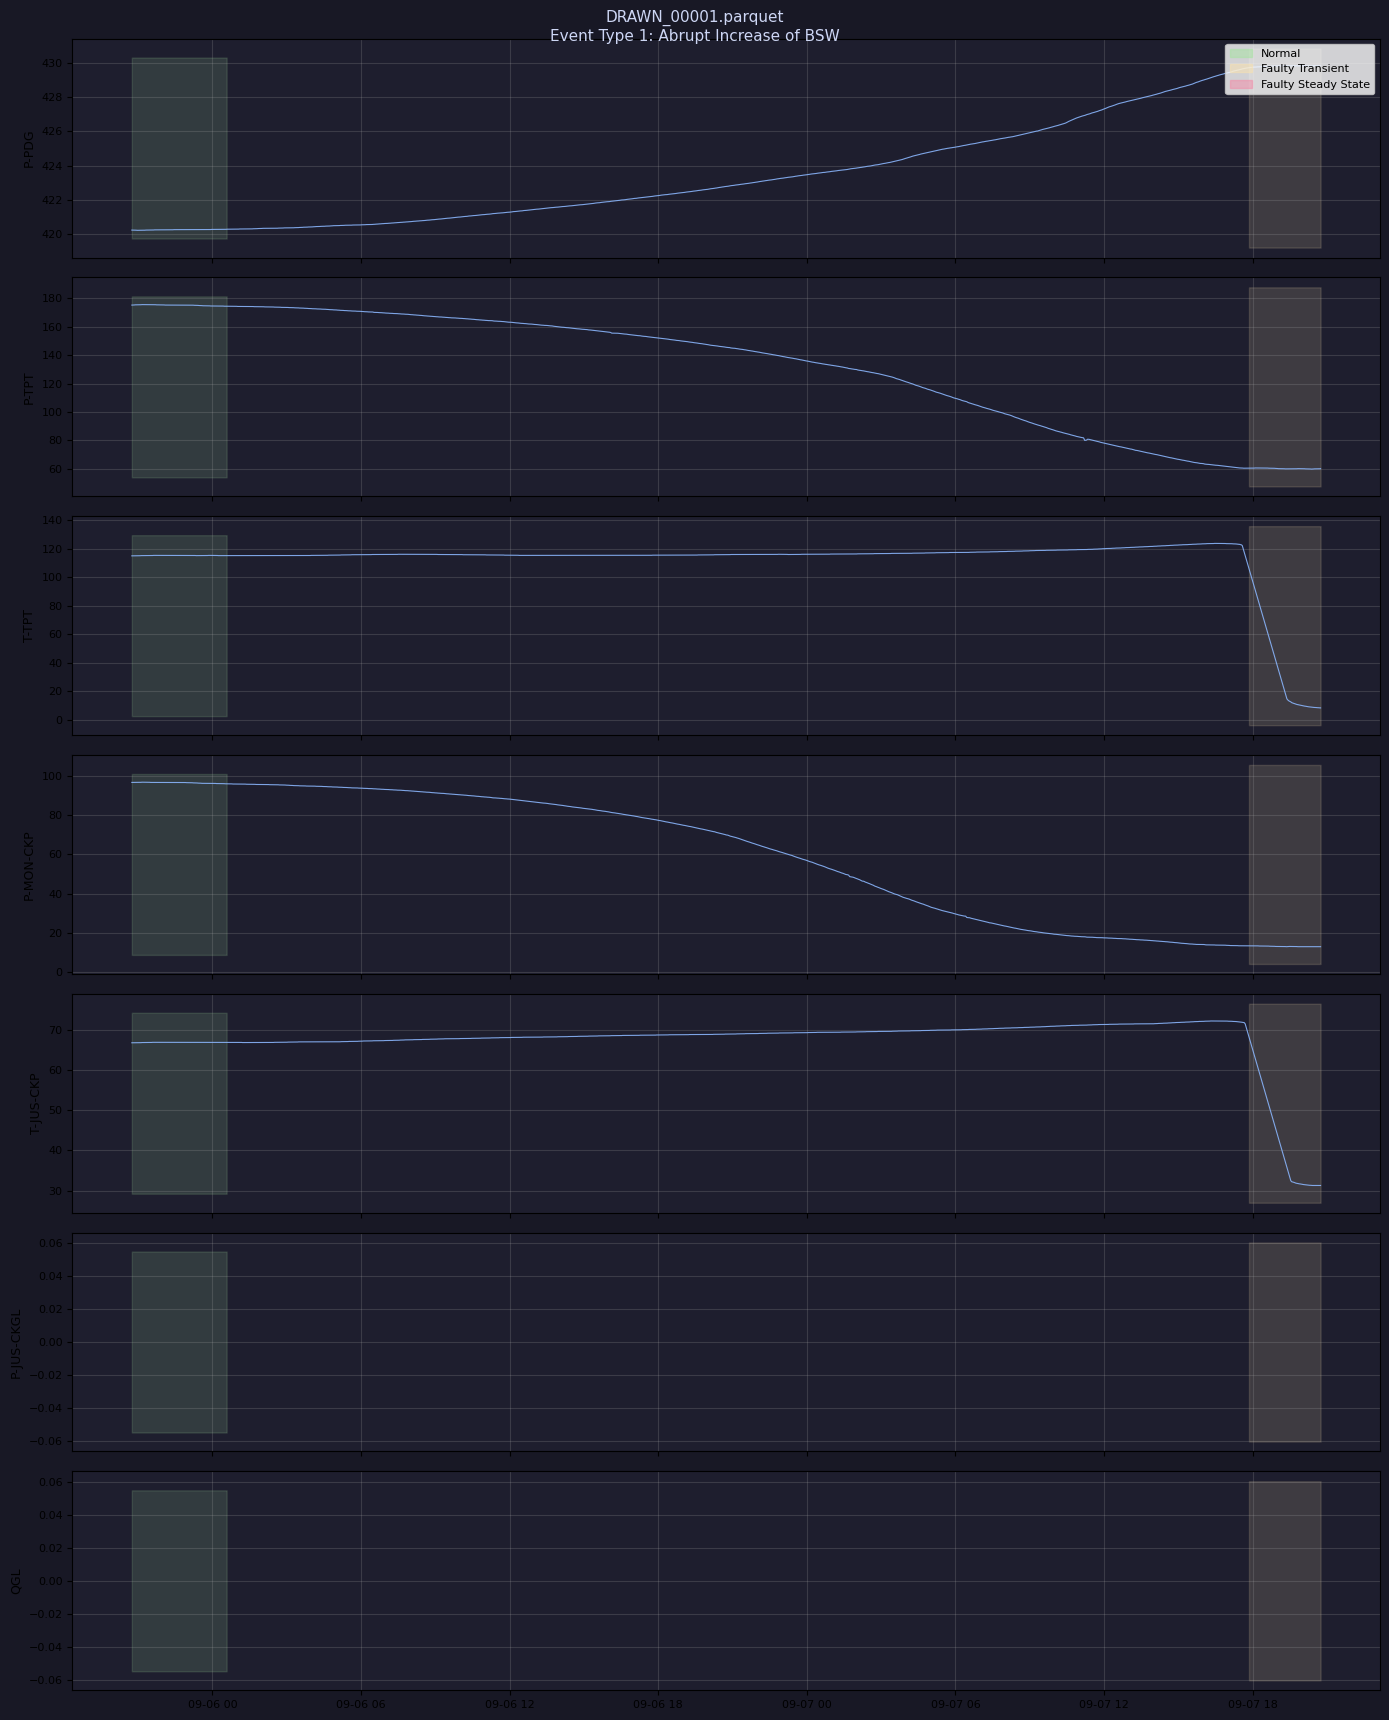

In [12]:
def plot_instance(df: pd.DataFrame, event_type: int, title: str = ''):
    """
    Visualizza i sensori di una istanza con le label di anomalia.
    Verde = normal, Giallo = faulty transient, Rosso = faulty steady state
    """
    available_sensors = [s for s in SENSORS if s in df.columns]
    n = len(available_sensors)
    
    fig, axes = plt.subplots(n, 1, figsize=(14, 2.5*n), sharex=True)
    if n == 1:
        axes = [axes]
    
    colors = {0: '#a6e3a1', 1: '#f9e2af', 2: '#f38ba8'}  # green, yellow, red
    
    for ax, sensor in zip(axes, available_sensors):
        ax.plot(df.index, df[sensor], color='#89b4fa', linewidth=0.8, alpha=0.9)
        
        # Colora lo sfondo per label
        for label, color in colors.items():
            mask = df['class'] == label
            if mask.any():
                ax.fill_between(df.index, ax.get_ylim()[0], ax.get_ylim()[1],
                               where=mask, alpha=0.15, color=color)
        
        ax.set_ylabel(sensor, fontsize=9)
        ax.set_facecolor('#1e1e2e')
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.2)
    
    legend = [
        mpatches.Patch(color='#a6e3a1', alpha=0.5, label='Normal'),
        mpatches.Patch(color='#f9e2af', alpha=0.5, label='Faulty Transient'),
        mpatches.Patch(color='#f38ba8', alpha=0.5, label='Faulty Steady State')
    ]
    axes[0].legend(handles=legend, loc='upper right', fontsize=8)
    
    fig.suptitle(f'{title}\nEvent Type {event_type}: {EVENT_TYPES[event_type]}',
                fontsize=11, color='#cdd6f4')
    fig.patch.set_facecolor('#181825')
    plt.tight_layout()
    plt.show()

if all_files:
    # Trova un'istanza con anomalia (type != 0)
    anomaly_files = [(c, f) for c, f in all_files if c != 0]
    if anomaly_files:
        event_code, sample_file = anomaly_files[0]
        df_plot = load_instance(sample_file)
        plot_instance(df_plot, event_code, sample_file.name)
else:
    print('⚠️  Scarica il dataset per visualizzare le istanze')

## 5. Class Imbalance

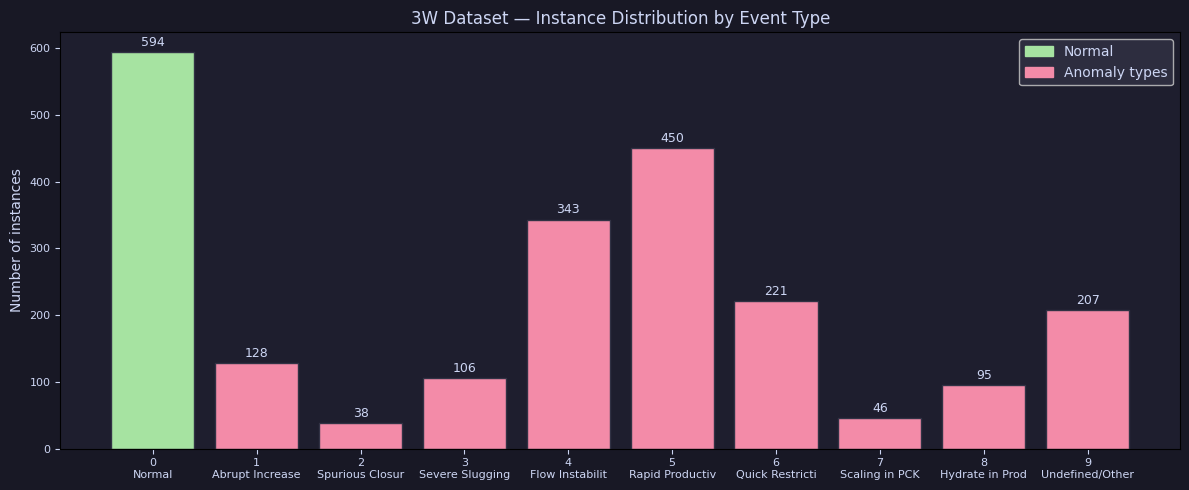


Class imbalance ratio (normal/rarest): 12.9x
→ Implication for TGN: use weighted BCE loss (as in Use Case 1)


In [ ]:
# Mostra la distribuzione delle classi (dal paper Table 2)
# Fondamentale per capire come configurare TGN e le metriche

expected_counts = {
    0: 597,   # Normal — maggioranza
    1: 129,   # Abrupt BSW
    2: 38,    # Spurious DHSV
    3: 106,   # Severe Slugging
    4: 344,   # Flow Instability — seconda classe più frequente
    5: 451,   # Rapid Productivity Loss
    6: 221,   # Quick Restriction PCK
    7: 14,    # Scaling PCK — più raro!
    8: 84,    # Hydrate
}

actual_counts = instance_counts if instance_counts else expected_counts

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#a6e3a1' if k == 0 else '#f38ba8' for k in actual_counts.keys()]
bars = ax.bar(
    [f"{k}\n{EVENT_TYPES[k][:15]}" for k in actual_counts.keys()],
    actual_counts.values(), # type: ignore
    color=colors_bar,
    edgecolor='#313244'
)

for bar, val in zip(bars, actual_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
           str(val), ha='center', va='bottom', fontsize=9, color='#cdd6f4')

ax.set_title('3W Dataset — Instance Distribution by Event Type', color='#cdd6f4')
ax.set_ylabel('Number of instances', color='#cdd6f4')
ax.set_facecolor('#1e1e2e')
fig.patch.set_facecolor('#181825')
ax.tick_params(colors='#cdd6f4', labelsize=8)

normal_patch = mpatches.Patch(color='#a6e3a1', label='Normal')
anomaly_patch = mpatches.Patch(color='#f38ba8', label='Anomaly types')
ax.legend(handles=[normal_patch, anomaly_patch], facecolor='#313244', labelcolor='#cdd6f4')

plt.tight_layout()
plt.savefig('../../experiments/class_distribution_3w.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClass imbalance ratio (normal/rarest): {actual_counts[0]/actual_counts[7]:.1f}x')
print('→ Implication for TGN: use weighted BCE loss (as in Use Case 1)')

## 6. TKG Design Decisions

Dalle analisi sopra, emergono 3 decisioni di design per il TKG:

| Decisione | Scelta | Giustificazione |
|---|---|---|
| **NaN handling** | Inferenza da sensori vicini nel grafo | Khan et al. [9]: graph structure provides redundant evidence paths |
| **PRECEDES relation** | PDG → TPT → PCK (ordine fisico) | Vargas et al. (2019): physical propagation downhole → surface |
| **CAUSALLY_COUPLED** | Pozzi sulla stessa piattaforma | Diamantini et al. [25]: process-aware IIoT knowledge graph |

**Nota sulla simultaneità:** il 3W non contiene istanze con più anomalie contemporanee (Vargas et al. 2019). Gestione di eventi simultanei è identificata come limitazione e lavoro futuro.

In [14]:
# Salva un riassunto del dataset per i notebook successivi
summary = {
    'dataset': '3W Dataset (Petrobras)',
    'source': 'Vargas et al. (2019), JPSE',
    'n_event_types': 8,
    'n_sensors': 8,
    'sensors': SENSORS,
    'sampling_rate_hz': 1,
    'event_types': EVENT_TYPES,
    'event_windows': EVENT_WINDOWS,
    'design_decisions': {
        'nan_handling': 'graph_neighbor_inference',
        'precedes_relation': True,
        'causally_coupled': True,
        'simultaneity': 'not_in_dataset_future_work'
    }
}

import json
os.makedirs('../../data/processed', exist_ok=True)
with open('../../data/processed/dataset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('✅ Summary salvato in data/processed/dataset_summary.json')
print('   Pronto per notebook 02_preprocessing.ipynb')

✅ Summary salvato in data/processed/dataset_summary.json
   Pronto per notebook 02_preprocessing.ipynb
